In [ ]:
import helpers
import importlib
from matplotlib.ticker import ScalarFormatter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
case_df = pd.read_excel("cases.xlsx")
case_df.head()

,case,solution_method,time_scheme,conv_scheme,RE,N,DX,DT_MAX,DT,CFL,URFP,URFU,diverging_factor,IT,clock_time,colour,compare_diff,plot,Coldumn3,Time (min)
0,1,EFSM,1,UDS,1000,16.0,0.062500,0.062500,0.1500,2.400,NaN,-1.0,0.2000,260.0,0.247447,C0,16.666667,25.0,10.4000,0.004124
1,2,EFSM,1,UDS,1000,32.0,0.031250,0.031250,0.0500,1.600,NaN,-1.0,0.1000,860.0,3.887910,C0,50.000000,100.0,8.6000,0.064799
2,3,EFSM,1,UDS,1000,64.0,0.015625,0.015625,0.0150,0.960,NaN,-1.0,0.0200,3322.0,44.980831,C0,166.666667,250.0,13.2880,0.749681
3,4,EFSM,1,UDS,1000,128.0,0.007812,0.007812,0.0050,0.640,NaN,-1.0,0.0100,11952.0,377.196014,C0,500.000000,1000.0,11.9520,6.286600
4,5,EFSM,1,UDS,1000,256.0,0.003906,0.003906,0.0015,0.384,NaN,-1.0,0.0025,43836.0,3393.875980,C1,1666.666667,5000.0,8.7672,56.564600


In [ ]:
importlib.reload(helpers)
CavityCase = helpers.CavityCase
CaseManager = helpers.CaseManager

groups = {
    "Explicit Euler QUICK": CaseManager([16,17,18,19,20], solution_method="EFSM", time_scheme=1, N=64, conv_scheme="quick", RE=1000),
    "Explicit Euler UDS": CaseManager([31,34,33,32, 35, 36,37], solution_method="EFSM", time_scheme=1, N=64, conv_scheme="uds", RE=1000),
    # "AB2": CaseManager([21,22,23,24,25], solution_method="EFSM", time_scheme=2, N=64, conv_scheme="quick", RE=1000),
    "SIMPLE": CaseManager([28], solution_method="simple", N=64, conv_scheme="uds", RE=1000)
}



In [ ]:
# groups["EFSM Explicit Euler"].compare_meta()
groups["Explicit Euler QUICK"].compare_meta().sort_values(by='DT').reset_index()

,index,solution_method,conv_scheme,RE,N,time_scheme,DT,clock_time,IT,sum_N,total_outer_iterations,total_inner_iterations,avg_inner_per_outer
0,20,fs,quick,1000.0,64,1,0.0005,76.141212,63517,3617,63517,72340,1.138908
1,19,fs,quick,1000.0,64,1,0.0010,47.817623,35260,2668,35260,53360,1.513330
2,18,fs,quick,1000.0,64,1,0.0050,34.663536,9328,6445,9328,128900,13.818611
3,17,fs,quick,1000.0,64,1,0.0100,48.560310,5552,10979,5552,219580,39.549712
4,16,fs,quick,1000.0,64,1,0.0150,61.849926,4202,14547,4202,290940,69.238458


In [96]:
groups["AB2"].compare_meta().sort_values(by='DT').reset_index()[['DT', 'IT']]-groups["Explicit Euler QUICK"].compare_meta().sort_values(by='DT').reset_index()[['DT', 'IT']]

,DT,IT
0,0.0,-17
1,0.0,2
2,0.0,11
3,0.0,-1
4,0.0,-12


In [ ]:
SIMPLE_groups = { "SIMPLE": CaseManager([28], solution_method="simple", N=64, conv_scheme="uds", RE=1000)}

In [202]:
EFSM_groups = {
    # "Explicit Euler QUICK": CaseManager([16,17,18,19,20], solution_method="EFSM", time_scheme=1, N=64, conv_scheme="quick", RE=1000),
    # "Explicit Euler UDS": CaseManager([31,34,33,32, 35, 36,37, 38, 39], solution_method="EFSM", time_scheme=1, N=64, conv_scheme="uds", RE=1000),
    "Explicit Euler UDS 64": CaseManager([40,41,42,43,45,46, 47], solution_method="EFSM", time_scheme=1, N=64, conv_scheme="uds", RE=1000),
    "Explicit Euler UDS 16": CaseManager([48,49,50,51,52,53,54, 55, 56, 57, 58], solution_method="EFSM", time_scheme=1, N=16, conv_scheme="uds", RE=1000),
}

In [180]:
EFSM_groups["Explicit Euler UDS"].compare_meta().sort_values(by='DT')

,solution_method,conv_scheme,RE,N,time_scheme,DT,clock_time,IT,sum_N,total_outer_iterations,total_inner_iterations,avg_inner_per_outer
40,fs,uds,1000.0,64,2,0.000156,175.099701,136659,8634,136659,172680,1.263583
41,fs,uds,1000.0,64,2,0.000781,58.603294,37155,3594,37155,71880,1.934598
42,fs,uds,1000.0,64,2,0.003125,60.159965,11825,9237,11825,184740,15.622833
33,fs,uds,1000.0,64,2,0.005000,77.035553,8051,11446,8051,228920,28.433735
43,fs,uds,1000.0,64,2,0.006250,87.384323,6706,20510,6706,410200,61.169102
38,fs,uds,1000.0,64,2,0.007500,95.118500,5759,29406,5759,588120,102.121896
44,fs,uds,1000.0,64,2,0.007812,97.289329,5560,29978,5560,599560,107.834532
45,fs,uds,1000.0,64,2,0.009375,107.397453,4791,33704,4791,674080,140.697140
46,fs,uds,1000.0,64,2,0.012500,127.491776,3717,34444,3717,688880,185.332257
47,fs,uds,1000.0,64,2,0.015625,142.694870,2987,35863,2987,717260,240.127218


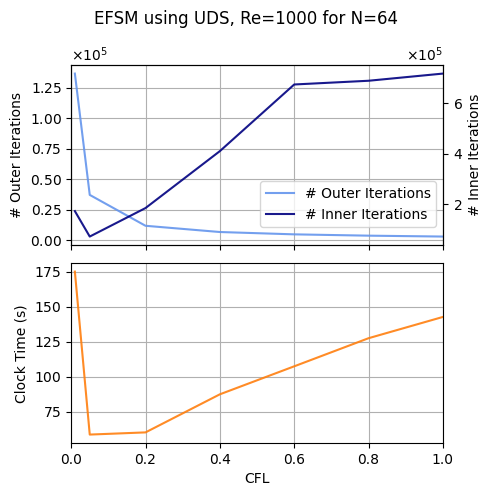

In [320]:


fig, axes = plt.subplots(2, 1, figsize=(5, 5), sharex=True)
time_scheme_dict = {1: "Explicit Euler", 2: "AB2"}

ax0_copy = axes[0].twinx()
for ax in [axes[0], axes[1], ax0_copy]:
    ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    
    ax.set_xlim(0,1.0)

# --- get first group only ---
group=CaseManager([40,41,42,43,45,46, 47], solution_method="EFSM", time_scheme=1, N=64, conv_scheme="uds", RE=1000)

meta_df =  group.compare_meta()
DX = 1 / meta_df['N']
meta_df['CFL'] = meta_df['DT'] / DX
meta_df = meta_df.sort_values(by='CFL')

label_outer = f"# Outer Iterations"
label_inner = "# Inner Iterations"

# Plot on main axis
l1, = axes[0].plot(meta_df['CFL'], meta_df["IT"], label=label_outer, alpha=0.9, linewidth=1.5, color="cornflowerblue", zorder=2)
# Plot on twin axis
l2, = ax0_copy.plot(meta_df['CFL'], meta_df["total_inner_iterations"], label=label_inner, alpha=0.9, linewidth=1.5, zorder=1, color="navy")
# Plot on second subplot
l3, = axes[1].plot(meta_df['CFL'], meta_df["clock_time"], label="Clock Time", alpha=0.9, linewidth=1.5, color="C1")

# Formatting
axes[0].set_ylabel("# Outer Iterations")
ax0_copy.set_ylabel("# Inner Iterations")
axes[0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax0_copy.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
axes[1].set_ylabel("Clock Time (s)")
axes[1].set_xlabel("CFL")
axes[0].grid()
axes[1].grid()

# --- Single combined legend ---
leg = axes[0].legend(handles=[l1, l2], loc='lower left', bbox_to_anchor=(0.49, 0.06), framealpha=0.8)
leg.set_zorder(10)

fig.subplots_adjust(wspace=0.35)
fig.suptitle("EFSM using UDS, Re=1000 for N=64")

fig.tight_layout(pad=1)

In [308]:
importlib.reload(helpers)
CavityCase = helpers.CavityCase
CaseManager = helpers.CaseManager
simple_group=CaseManager([59,60,61,62,63, 64,65,66], solution_method="SIMPLE", N=64, conv_scheme="uds", RE=1000)

In [301]:
simple_group.cases.keys()

dict_keys([59, 60, 61, 62, 63, 64, 65])

In [306]:
case_df = pd.read_excel("cases.xlsx")


Convergence dataframe is empty!


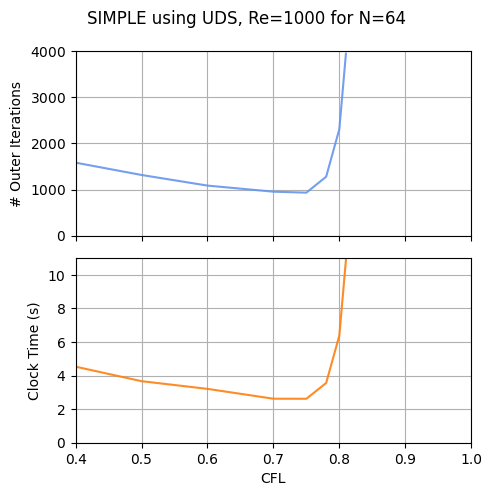

In [319]:
case_df = pd.read_excel("cases.xlsx")
case_df.head()

fig, axes = plt.subplots(2, 1, figsize=(5, 5), sharex=True)
time_scheme_dict = {1: "Explicit Euler", 2: "AB2"}


for ax in [axes[0], axes[1], ax0_copy]:
    ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax.set_xlim(0.4,1.0)

# --- get first group only ---
group=simple_group
meta_df =  group.compare_meta()
DX = 1 / meta_df['N']

label_outer = f"# Outer Iterations"
label_inner = "# Inner Iterations"

# Plot on main axis
case_df_slice = case_df[case_df["case"].isin(list(simple_group.cases.keys()))].copy().sort_values(by="URFU")
IT=case_df[case_df["case"].isin(list(simple_group.cases.keys()))]['IT']

l1, = axes[0].plot(case_df_slice['URFU'], case_df_slice["IT"], '-',label=label_outer, alpha=0.9, linewidth=1.5, color="cornflowerblue", zorder=2)
# Plot on twin axis

# Plot on second subplot
l3, = axes[1].plot(case_df_slice['URFU'], case_df_slice["clock_time"], label="Clock Time", alpha=0.9, linewidth=1.5, color="C1")

# Formatting
axes[0].set_ylabel("# Outer Iterations")
# axes[0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))

axes[1].set_ylabel("Clock Time (s)")
axes[1].set_xlabel("CFL")
axes[0].grid()
axes[1].grid()

axes[0].set_ylim(0,4000)
axes[1].set_ylim(0,11)
fig.subplots_adjust(wspace=0.35)
fig.suptitle("SIMPLE using UDS, Re=1000 for N=64")

fig.tight_layout(pad=1)

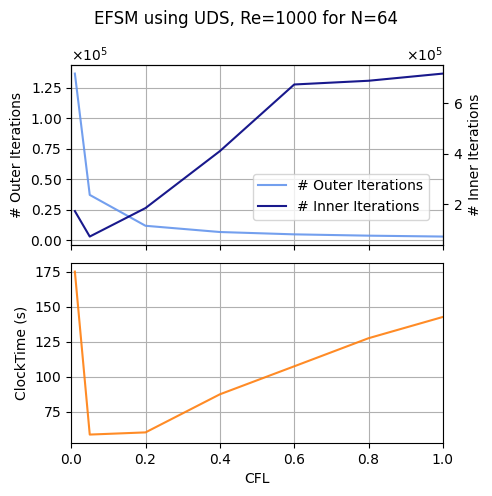

In [ ]:

fig, axes = plt.subplots(2, 1, figsize=(5, 5), sharex=True)
time_scheme_dict = {1: "Explicit Euler", 2: "AB2"}

ax0_copy = axes[0].twinx()
for ax in [axes[0], axes[1], ax0_copy]:
    ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    
    ax.set_xlim(0,1.0)
for i, (group_name, group) in enumerate(EFSM_groups.items()):
    meta_df = group.compare_meta()
    DX = 1 / meta_df['N']
    meta_df['CFL'] = meta_df['DT'] / DX
    meta_df = meta_df.sort_values(by='CFL')

    label_outer = f"# Outer Iterations"
    label_inner = "# Inner Iterations"

    # Plot on main axis
    l1, = axes[0].plot(meta_df['CFL'], meta_df["IT"], label=label_outer, alpha=0.9, linewidth=1.5, color="cornflowerblue",zorder=2)
    # Plot on twin axis
    l2, = ax0_copy.plot(meta_df['CFL'], meta_df["total_inner_iterations"], label=label_inner, alpha=0.9, linewidth=1.5, zorder=1, color="navy")
    # Plot on second subplot
    l3, = axes[1].plot(meta_df['CFL'], meta_df["clock_time"], label="Clock Time", alpha=0.9, linewidth=1.5, color="C1")
    break
# Formatting


axes[0].set_ylabel("# Outer Iterations")
ax0_copy.set_ylabel("# Inner Iterations")
axes[0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax0_copy.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
axes[1].set_ylabel("ClockTime (s)")
axes[1].set_xlabel("CFL")
axes[0].grid()
axes[1].grid()
# --- Single combined legend ---
leg = axes[0].legend(handles=[l1, l2],loc='lower left', bbox_to_anchor=(0.47, 0.1), framealpha=0.8)
leg.set_zorder(10)
fig.subplots_adjust(wspace=0.35)
fig.suptitle("EFSM using UDS, Re=1000 for N=64")

fig.tight_layout(pad=1)

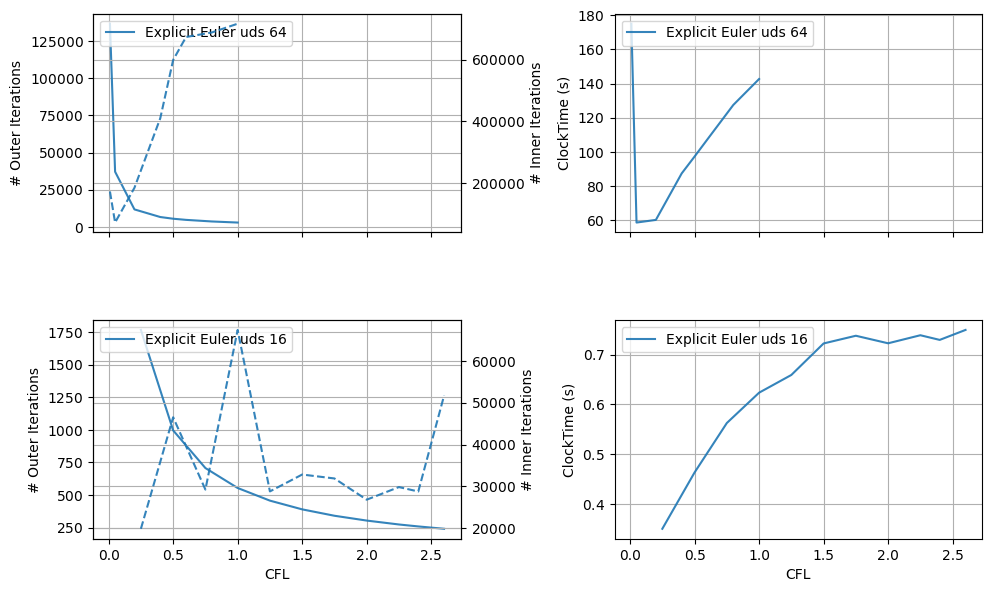

In [187]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import ScalarFormatter

time_scheme_dict = {1: "Explicit Euler", 2: "AB2"}

# Number of groups
n_groups = len(EFSM_groups)

# Create subplots: n rows, 2 columns (line + bar or line + twin)
fig, axes = plt.subplots(n_groups, 2, figsize=(10, 3*n_groups), sharex=True)

# Make axes 2D if only 1 row
if n_groups == 1:
    axes = np.array([axes])

for i, (group_name, group) in enumerate(EFSM_groups.items()):
    meta_df = group.compare_meta()
    DX = 1 / meta_df['N']
    meta_df['CFL'] = meta_df['DT'] / DX
    meta_df = meta_df.sort_values(by='CFL')
    
    label = f"{time_scheme_dict[group.time_scheme]} {group.conv_scheme} {group.N}"
    
    # --- Left subplot: iterations ---
    ax_iter = axes[i,0]
    ax_iter.plot(meta_df['CFL'], meta_df["IT"], label=label, linewidth=1.5, alpha=0.9)
    
    # Add twin axis for inner iterations
    ax_inner = ax_iter.twinx()
    ax_inner.plot(meta_df['CFL'], meta_df["total_inner_iterations"], label=label, linewidth=1.5, alpha=0.9, linestyle='--')
    
    # --- Right subplot: clock time ---
    ax_time = axes[i,1]
    ax_time.plot(meta_df['CFL'], meta_df["clock_time"], label=label, linewidth=1.5, alpha=0.9)

    # --- Formatting ---
    for ax in [ax_iter, ax_inner, ax_time]:
        ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
        ax.grid(which='major')
        ax.grid(which='minor', alpha=0.5)
    
    ax_iter.set_ylabel("# Outer Iterations")
    ax_inner.set_ylabel("# Inner Iterations")
    ax_time.set_ylabel("ClockTime (s)")
    
    if i == n_groups - 1:
        # Only bottom row gets x-label
        ax_iter.set_xlabel("CFL")
        ax_time.set_xlabel("CFL")
    
    # Add legends
    ax_iter.legend(loc='upper left')
    ax_time.legend(loc='upper left')

# Adjust layout
fig.tight_layout(pad=1)
fig.subplots_adjust(hspace=0.4)  # space between rows

plt.show()